005x数据集使用深度学习方法，改善nlos环境表现

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from sklearn.manifold import trustworthiness
from scipy.stats import ks_2samp
from tqdm import tqdm

# ==========================================
# 1. 配置参数
# ==========================================
# 请确保这些文件存在
INPUT_PATHS = [
    {"tfrecords": "dichasus/dichasus-0053.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-005x.json"},
    {"tfrecords": "dichasus/dichasus-0054.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-005x.json"},
    {"tfrecords": "dichasus/dichasus-0055.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-005x.json"},
    {"tfrecords": "dichasus/dichasus-0056.tfrecords", "offsets": "dichasus/reftx-offsets-dichasus-005x.json"},
]

ANTENNA_COUNT = 32
SUBCARRIERS = 1024
BATCH_SIZE = 32

2026-01-26 12:14:46.056518: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-26 12:14:46.483574: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-26 12:14:48.670837: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 数据加载与预处理

In [12]:
import tensorflow as tf
import numpy as np

# 1. 设置文件路径 (任选一个 tfrecords 文件即可)
# 确保路径与您 INPUT_PATHS 中的路径一致
file_path = "dichasus/dichasus-0053.tfrecords" 

print(f"正在检查文件: {file_path} ...\n")

# 2. 读取原始数据集
raw_dataset = tf.data.TFRecordDataset(file_path)

# 3. 取出第一条记录进行解析
for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    
    print("="*40)
    print(f"【发现的所有字段 (Keys)】: {list(example.features.feature.keys())}")
    print("="*40)
    
    # 4. 遍历每个字段，尝试推断维度
    for key, feature in example.features.feature.items():
        # 获取字段类型 (bytes, float, int64)
        kind = feature.WhichOneof('kind')
        print(f"\n>> Field: '{key}'")
        
        if kind == 'bytes_list':
            # 大多数 Tensor (如 csi, pos) 都是以 bytes 形式存储的序列化 Tensor
            byte_data = feature.bytes_list.value[0]
            print(f"   Storage Type: Bytes (Length: {len(byte_data)})")
            
            # 尝试解析为 float32 或 float64 Tensor 来查看维度
            parsed = False
            for dtype in [tf.float32, tf.float64, tf.int64]:
                try:
                    tensor = tf.io.parse_tensor(byte_data, out_type=dtype)
                    if tensor is not None:
                        print(f"   [解析成功] Tensor Dtype: {dtype.name}")
                        print(f"   [解析成功] Shape: {tensor.shape}")
                        print(f"   [数据示例]: {tensor.numpy().flatten()[:3]} ...")
                        parsed = True
                        break
                except:
                    continue
            if not parsed:
                print("   [提示] 无法自动解析为 Tensor，可能是纯字符串或图片数据。")
                
        elif kind == 'float_list':
            # 普通的 float 列表
            values = feature.float_list.value
            print(f"   Storage Type: FloatList")
            print(f"   Value: {values}")
            
        elif kind == 'int64_list':
            # 普通的 int 列表
            values = feature.int64_list.value
            print(f"   Storage Type: Int64List")
            print(f"   Value: {values}")

print("\n检查完成。")

正在检查文件: dichasus/dichasus-0053.tfrecords ...

【发现的所有字段 (Keys)】: ['pos-lidar', 'snr', 'csi', 'time', 'rot-lidar', 'cfo']

>> Field: 'pos-lidar'
   Storage Type: Bytes (Length: 26)
   [解析成功] Tensor Dtype: float64
   [解析成功] Shape: (2,)
   [数据示例]: [ 0.006 -0.066] ...

>> Field: 'snr'
   Storage Type: Bytes (Length: 139)
   [解析成功] Tensor Dtype: float32
   [解析成功] Shape: (32,)
   [数据示例]: [28.415056 22.343811 17.865992] ...

>> Field: 'csi'
   Storage Type: Bytes (Length: 262165)
   [解析成功] Tensor Dtype: float32
   [解析成功] Shape: (32, 1024, 2)
   [数据示例]: [4.677066  5.6480703 4.847598 ] ...

>> Field: 'time'
   Storage Type: FloatList
   Value: [4790.5439453125]

>> Field: 'rot-lidar'
   Storage Type: FloatList
   Value: [-0.024000000208616257]

>> Field: 'cfo'
   Storage Type: Bytes (Length: 139)
   [解析成功] Tensor Dtype: float32
   [解析成功] Shape: (32,)
   [数据示例]: [-4914.2397 -4913.8115 -4913.9414] ...

检查完成。


2026-01-26 13:16:15.151821: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
def load_dataset_005x(path, offset_path):
    offsets = None
    if os.path.exists(offset_path):
        with open(offset_path, "r") as f:
            offsets = json.load(f)
    
    #加载解析
    def record_parse_function(proto):
        record = tf.io.parse_single_example(
            proto,
            {
                "csi": tf.io.FixedLenFeature([], tf.string, default_value=""),
                "pos-lidar": tf.io.FixedLenFeature([], tf.string, default_value=""),
                "time": tf.io.FixedLenFeature([], tf.float32, default_value=0),
            },
        )
        # CSI
        csi = tf.io.parse_tensor(record["csi"], out_type=tf.float32)
        csi = tf.ensure_shape(csi, (ANTENNA_COUNT, SUBCARRIERS, 2))
        csi_complex = tf.complex(csi[:, :, 0], csi[:, :, 1])
        csi_complex = tf.signal.fftshift(csi_complex, axes=1)  #形状为(32,1024)
        

        # Position (005x 使用 pos-lidar, 通常只有 x, y)
        pos = tf.io.parse_tensor(record["pos-lidar"], out_type=tf.float64)
        pos = tf.ensure_shape(pos, (2,)) 
        pos = tf.cast(pos, tf.float32)

        return csi_complex, pos

    #校准
    def apply_calibration(csi, pos):
        if offsets:
            sto_offset = tf.tensordot(tf.constant(offsets["sto"], dtype=tf.float32), 
                                      2 * np.pi * tf.range(SUBCARRIERS, dtype=tf.float32) / float(SUBCARRIERS), axes=0)
            cpo_offset = tf.tensordot(tf.constant(offsets["cpo"], dtype=tf.float32), 
                                      tf.ones(SUBCARRIERS, dtype=tf.float32), axes=0)
            calib_factor = tf.exp(tf.complex(0.0, sto_offset + cpo_offset))
            csi = tf.multiply(csi, calib_factor)
        return csi, pos

    
    #特征预处理
    def preprocess_features(csi, pos):
        # 提取幅度与相位
        mag = tf.math.abs(csi)  #(32,1024)
        mag = tf.math.log(mag + 1e-6) # 对数幅度
        mag = (mag - 0.0) / 5.0       # 简单归一化
        
        phase = tf.math.angle(csi)  #(32,1024)
        phase = phase / np.pi         # 归一化 [-1, 1]

        features = tf.stack([mag, phase], axis=-1) # (32, 1024, 2)
        return features, pos

    ds = tf.data.TFRecordDataset(path)
    ds = ds.map(record_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(apply_calibration, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(preprocess_features, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

## 模型架构

In [ ]:
class SqueezeAndExcitation(layers.Layer):
    def __init__(self, channels, ratio=16, **kwargs):
        super().__init__(**kwargs)
        #压缩
        self.avg_pool = layers.GlobalAveragePooling2D()  #将每个通道的二维特征图压缩为一个实数，捕捉了全局感受野
        #激励
        self.dense1 = layers.Dense(channels // ratio, activation='relu') # 减少参数量并增加非线性
        self.dense2 = layers.Dense(channels, activation='sigmoid') # 通道恢复原始大小，并激活，代表每个通道的重要性权重
        
    def call(self, inputs):
        x = self.avg_pool(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = tf.reshape(x, (-1, 1, 1, inputs.shape[-1]))
        return inputs * x  # 将计算出的权重乘回原始输入特征。重要的特征被放大，不重要的被抑制

def build_model():
    input_shape = (ANTENNA_COUNT, SUBCARRIERS, 2)
    inputs = layers.Input(shape=input_shape)
    
    # 简单的 Conv
    x = layers.Conv2D(32, (3, 7), padding='same', strides=(1, 2))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # 残差块函数
    def res_se_block(x, filters):
        shortcut = x  # 保存原始输入
        if x.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)

        # (3,3)卷积+BN+relu
        y = layers.Conv2D(filters, (3, 3), padding='same')(x)
        y = layers.BatchNormalization()(y)
        y = layers.Activation('relu')(y)
        # (3,3)卷积+BN
        y = layers.Conv2D(filters, (3, 3), padding='same')(y)
        y = layers.BatchNormalization()(y)
        # 注意力机制引入权重
        y = SqueezeAndExcitation(filters)(y)
        # 加权后的特征y与原始输入相加
        y = layers.Add()([y, shortcut])
        # 最终进行激活
        y = layers.Activation('relu')(y)
        return y

    x = res_se_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)
    x = res_se_block(x, 128)
    x = layers.MaxPooling2D((2, 2))(x)
    x = res_se_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(2)(x) # 输出 x, y
    
    return models.Model(inputs=inputs, outputs=outputs)

## 训练

In [ ]:
full_dataset = None
for inp in INPUT_PATHS:
    ds = load_dataset_005x(inp["tfrecords"], inp["offsets"])
    full_dataset = ds if full_dataset is None else full_dataset.concatenate(ds)

print("正在统计数据集总数，请稍候...")
# 关键修复：真实统计数量，防止 ValueError
TOTAL_SAMPLES = sum(1 for _ in full_dataset)
print(f"数据集总样本数: {TOTAL_SAMPLES}")

# 70% 训练 - 15% 验证 - 15% 测试
train_size = int(0.7 * TOTAL_SAMPLES)
val_size = int(0.15 * TOTAL_SAMPLES)
test_size = TOTAL_SAMPLES - train_size - val_size

full_dataset = full_dataset.shuffle(buffer_size=2000, seed=42)
train_ds = full_dataset.take(train_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = full_dataset.skip(train_size).take(val_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = full_dataset.skip(train_size + val_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"划分: 训练 {train_size}, 验证 {val_size}, 测试 {test_size}")

正在统计数据集总数，请稍候...
数据集总样本数: 21160
划分: 训练 14811, 验证 3174, 测试 3175


In [27]:
model = build_model()
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # mae 在这里即 mean distance error 的近似

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # 演示用 20，实际建议 50+
    callbacks=[callbacks.ReduceLROnPlateau(patience=5), callbacks.EarlyStopping(patience=10)]
)

Epoch 1/20
    462/Unknown 29s 34ms/step - loss: 0.9082 - mae: 0.7078

2026-01-23 08:35:57.725786: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-23 08:35:57.725842: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-23 08:35:58.368494: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3444', 12 bytes spill stores, 12 bytes spill loads

2026-01-23 08:35:58.400773: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning :

    463/Unknown 42s 62ms/step - loss: 0.9077 - mae: 0.7076

/workspace/anaconda/envs/py39/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


463/463 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - loss: 0.9072 - mae: 0.7074 - val_loss: 1.1958 - val_mae: 0.8400 - learning_rate: 0.0010
Epoch 2/20


...

463/463 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.1109 - mae: 0.2444 - val_loss: 0.1003 - val_mae: 0.2260 - learning_rate: 0.0010
Epoch 17/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.1075 - mae: 0.2417 - val_loss: 0.0818 - val_mae: 0.1962 - learning_rate: 0.0010
Epoch 18/20


2026-01-23 08:41:53.338752: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11875540432442093135


463/463 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.1037 - mae: 0.2352 - val_loss: 0.0938 - val_mae: 0.2186 - learning_rate: 0.0010
Epoch 19/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.0942 - mae: 0.2252 - val_loss: 0.1265 - val_mae: 0.2509 - learning_rate: 0.0010
Epoch 20/20


2026-01-23 08:42:34.920857: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4413837595069489498
2026-01-23 08:42:34.920890: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11875540432442093135


463/463 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.1020 - mae: 0.2346 - val_loss: 0.1038 - val_mae: 0.2184 - learning_rate: 0.0010


## 可视化评估

In [28]:
# ==========================================
# 修复后的评估与可视化代码 (独立运行版)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from sklearn.manifold import trustworthiness
from scipy.stats import ks_2samp
import numpy as np
import tensorflow as tf

# 1. 【修复 NameError】定义采样数
# 用于计算耗时的流形指标(TW/CT)和绘制散点图(避免过于密集)
EVAL_SAMPLES = 2000 

print("正在准备全量评估数据 (可能需要一点时间)...")

# 2. 重新遍历测试集，确保获取对应的 y_pred, y_true 和 高维特征 X
y_true_list = []
y_pred_list = []
X_features_list = [] # 用于计算 TW/CT

# 计数器，用于控制仅提取部分高维特征以节省内存
count = 0 

for batch_x, batch_y in test_ds:
    # 预测全量数据
    preds = model.predict(batch_x, verbose=0)
    
    y_true_list.append(batch_y.numpy())
    y_pred_list.append(preds)
    
    # 仅收集前 EVAL_SAMPLES 个样本的特征用于流形计算
    if count < EVAL_SAMPLES:
        # 提取幅度通道 (batch, 32, 1024, 2) -> 取 index 0 -> Flatten
        # 这里的 batch_x[..., 0] 对应幅度信息
        flat_feats = tf.reshape(batch_x[..., 0], (batch_x.shape[0], -1)).numpy()
        X_features_list.append(flat_feats)
        count += batch_x.shape[0]

# 合并为 Numpy 数组
y_true = np.concatenate(y_true_list, axis=0) # 全量真实值
y_pred = np.concatenate(y_pred_list, axis=0) # 全量预测值

# 截取用于流形指标计算的子集
# 注意：X_features_list 可能比 EVAL_SAMPLES 稍微多一点(因为是按batch添加的)，这里强制截断对齐
min_len = min(len(y_pred), EVAL_SAMPLES)
X_high_dim = np.concatenate(X_features_list, axis=0)[:min_len]
y_pred_sub = y_pred[:min_len] # 对应的低维嵌入子集
y_true_sub = y_true[:min_len] # 对应的真实值子集

print(f"数据准备完毕。全量样本数: {len(y_pred)}, 流形评估子集数: {min_len}")

# --- 3. 计算各项指标 ---

# (1) MAE (平均定位误差) - 【使用全量 y_pred】
errors = np.linalg.norm(y_true - y_pred, axis=1)
mae = np.mean(errors)

# (2) KS (分布一致性) - 【使用全量 y_pred】
ks_x = ks_2samp(y_true[:, 0], y_pred[:, 0]).statistic
ks_y = ks_2samp(y_true[:, 1], y_pred[:, 1]).statistic
ks_score = (ks_x + ks_y) / 2.0

# (3) TW & CT (流形质量) - 【使用子集，否则计算量太大】
print("正在计算流形指标 (TW/CT)...")
# TW: 衡量高维空间的邻居是否被保留到了低维 (Trustworthiness)
tw_score = trustworthiness(X_high_dim, y_pred_sub, n_neighbors=5, metric='euclidean')

# CT: 衡量低维空间的邻居是否也是高维的 (Continuity)
# 注意：trustworthiness 函数参数反过来传就是 Continuity
ct_score = trustworthiness(y_pred_sub, X_high_dim, n_neighbors=5, metric='euclidean')

print("\n" + "="*40)
print("           核心评估指标汇报")
print("="*40)
print(f"MAE (平均定位误差)    : {mae:.4f} m  (全量数据)")
print(f"KS  (分布差异统计量)  : {ks_score:.4f} (全量数据)")
print(f"TW  (可信度/邻域保持): {tw_score:.4f} (子集评估)")
print(f"CT  (连续性/流形断裂): {ct_score:.4f} (子集评估)")
print("="*40)



正在准备全量评估数据 (可能需要一点时间)...
数据准备完毕。全量样本数: 3175, 流形评估子集数: 2000
正在计算流形指标 (TW/CT)...

           核心评估指标汇报
MAE (平均定位误差)    : 0.3415 m  (全量数据)
KS  (分布差异统计量)  : 0.0550 (全量数据)
TW  (可信度/邻域保持): 0.7871 (子集评估)
CT  (连续性/流形断裂): 0.9140 (子集评估)


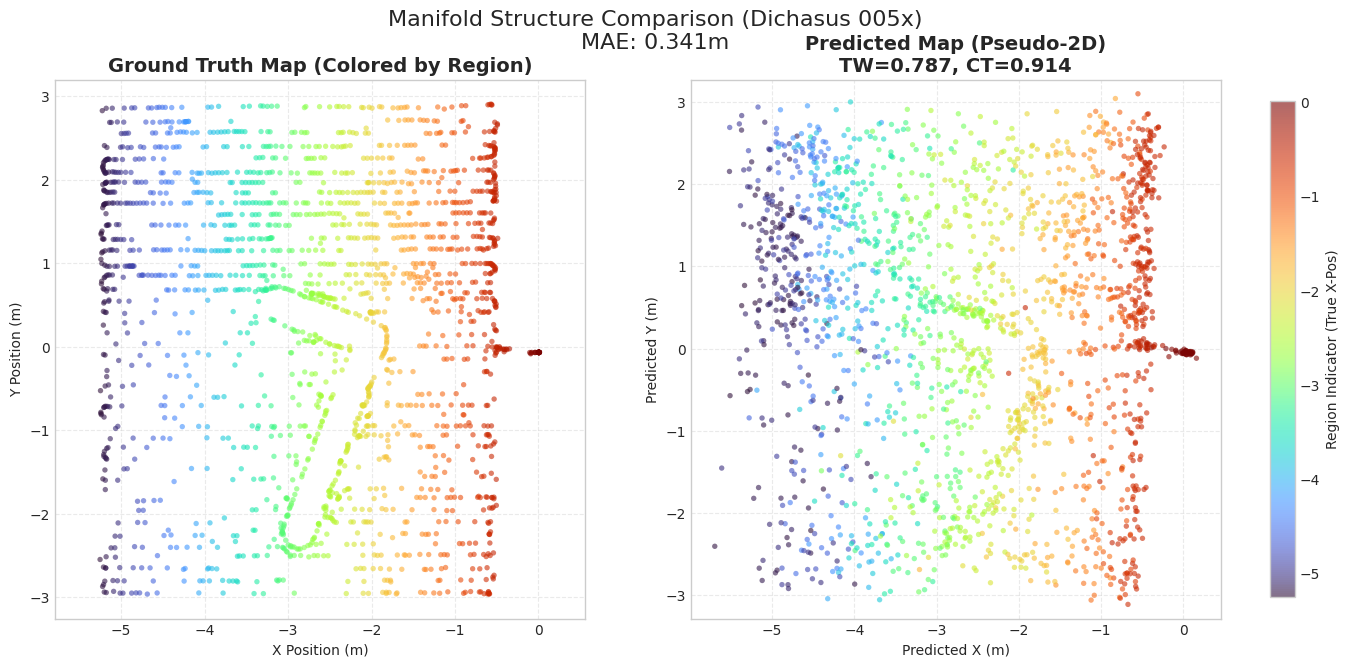

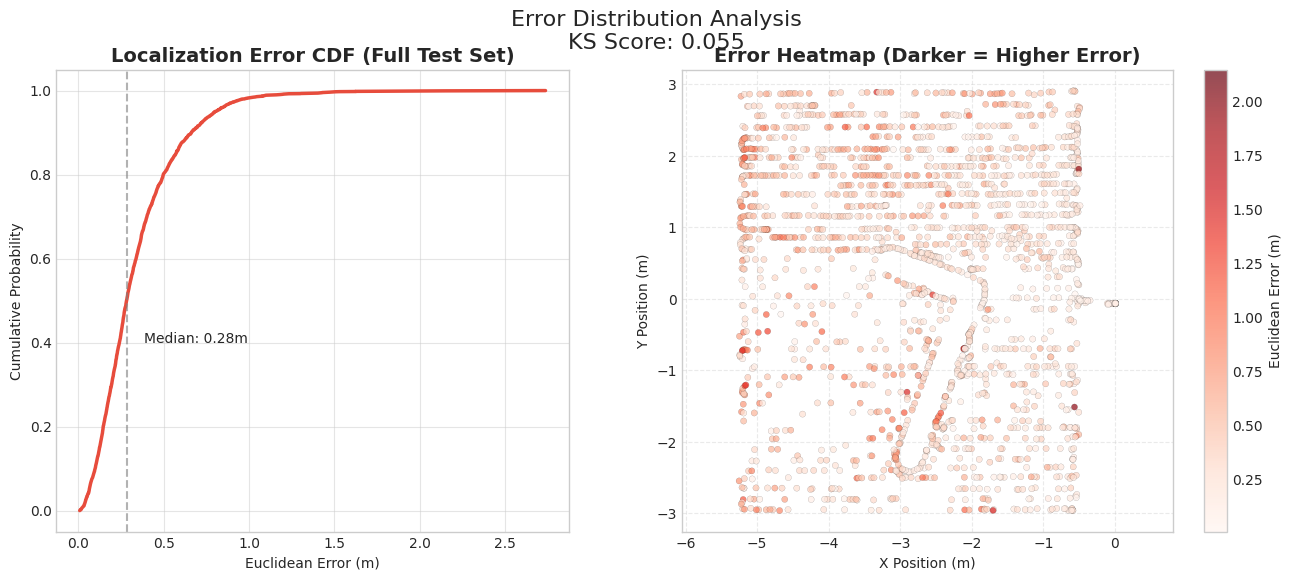

In [29]:
# --- 4. 绘图部分 ---
# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')

# 颜色映射：根据真实坐标的 X 轴位置生成颜色，形成彩虹带
# 使用子集绘图以保持图表清晰，且对应 TW/CT 的样本
colors = y_true_sub[:, 0] 

# ========== 图表 1: 区域映射对比 (Maps Comparison) ==========
fig1 = plt.figure(figsize=(16, 7))
gs1 = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# 子图 1: Ground Truth (真实流形)
ax1 = plt.subplot(gs1[0])
sc1 = ax1.scatter(y_true_sub[:, 0], y_true_sub[:, 1], c=colors, cmap='turbo', s=15, alpha=0.6, edgecolors='none')
ax1.set_title(f'Ground Truth Map (Colored by Region)', fontsize=14, fontweight='bold')
ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.axis('equal')
ax1.grid(True, linestyle='--', alpha=0.4)

# 子图 2: Prediction (预测流形)
ax2 = plt.subplot(gs1[1])
sc2 = ax2.scatter(y_pred_sub[:, 0], y_pred_sub[:, 1], c=colors, cmap='turbo', s=15, alpha=0.6, edgecolors='none')
ax2.set_title(f'Predicted Map (Pseudo-2D)\nTW={tw_score:.3f}, CT={ct_score:.3f}', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted X (m)')
ax2.set_ylabel('Predicted Y (m)')
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.4)

# 添加颜色条
cbar = fig1.colorbar(sc1, ax=[ax1, ax2], fraction=0.02, pad=0.04)
cbar.set_label('Region Indicator (True X-Pos)', fontsize=10)

plt.suptitle(f"Manifold Structure Comparison (Dichasus 005x)\nMAE: {mae:.3f}m", fontsize=16)
plt.show()

# ========== 图表 2: 误差分析 (Error Analysis) ==========
fig2 = plt.figure(figsize=(16, 6))
gs2 = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])

# 子图 1: CDF 曲线 (累积分布函数) - 【使用全量 errors】
sorted_errors = np.sort(errors)
p = 1. * np.arange(len(errors)) / (len(errors) - 1)
ax3 = plt.subplot(gs2[0])
ax3.plot(sorted_errors, p, linewidth=2.5, color='#e74c3c')
# 标注中位数和90%分位
p50 = sorted_errors[int(len(errors)*0.5)]
p90 = sorted_errors[int(len(errors)*0.9)]
ax3.axvline(p50, color='gray', linestyle='--', alpha=0.6)
ax3.text(p50+0.1, 0.4, f'Median: {p50:.2f}m', fontsize=10)
ax3.set_title('Localization Error CDF (Full Test Set)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Euclidean Error (m)')
ax3.set_ylabel('Cumulative Probability')
ax3.grid(True, alpha=0.5)

# 子图 2: 误差空间分布热力图 - 【使用子集绘图】
ax4 = plt.subplot(gs2[1])
# 颜色深浅表示误差大小
error_subset = np.linalg.norm(y_true_sub - y_pred_sub, axis=1)
sc4 = ax4.scatter(y_true_sub[:, 0], y_true_sub[:, 1], c=error_subset, cmap='Reds', s=20, alpha=0.7, edgecolors='k', linewidth=0.1)
ax4.set_title('Error Heatmap (Darker = Higher Error)', fontsize=14, fontweight='bold')
ax4.set_xlabel('X Position (m)')
ax4.set_ylabel('Y Position (m)')
ax4.axis('equal')
ax4.grid(True, linestyle='--', alpha=0.4)

cbar4 = fig2.colorbar(sc4, ax=ax4)
cbar4.set_label('Euclidean Error (m)', fontsize=10)

plt.suptitle(f"Error Distribution Analysis\nKS Score: {ks_score:.3f}", fontsize=16)
plt.show()